In [1]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [2]:


filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

# To start with, lets use 100ns and 5 mw as a pre_alpha_event selection

In [ ]:
E_std=lh5.read("ch002/hit/trapEftp_fix_cal",run_db['s100ns_mw5']["phy_signal_pathlist"])
A_max_mw_o_E_Classifier_std=lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db['s100ns_mw5']["phy_signal_pathlist"])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5']["phy_signal_pathlist"])
is_valid_waveform_std = lh5.read("ch002/hit/is_valid_waveform",run_db['s100ns_mw5']["phy_signal_pathlist"])
A_max_mw_o_E_High_Side_Cut_std = lh5.read("ch002/hit/A_max_mw_o_E_High_Side_Cut",run_db['s100ns_mw5']["phy_signal_pathlist"])

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x7fdf4240ec00>
Traceback (most recent call last):
  File "/mnt/atlas02/users/leoli/.conda/envs/leolienv/lib/python3.13/weakref.py", line 105, in remove
    def remove(wr, selfref=ref(self), _atomic_removal=_remove_dead_weakref):
KeyboardInterrupt: 


In [ ]:
E_std = np.asarray(E_std)
A_max_mw_o_E_Classifier_std = np.asarray(A_max_mw_o_E_Classifier_std)
Iasy_std = np.asarray(Iasy_std)
is_valid_waveform_std = np.asarray(is_valid_waveform_std)
A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)

In [ ]:
E_mask = (E_std >= 1839) & (E_std < 2239)
is_not_alpha = (Iasy_std<0) & A_max_mw_o_E_High_Side_Cut_std
ROI_mask = E_mask & is_not_alpha & is_valid_waveform_std

In [ ]:
A_max_mw_o_E_Classifier = {}
A_max_mw_o_E_Low_Cut = {}
for run in runs:
    A_max_mw_o_E_Classifier[run] = lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db[run]["phy_signal_pathlist"])
    A_max_mw_o_E_Low_Cut[run] = lh5.read("ch002/hit/A_max_mw_o_E_Low_Cut",run_db[run]["phy_signal_pathlist"])
    

In [ ]:
for run in runs:
    A_max_mw_o_E_Classifier[run] = np.asarray(A_max_mw_o_E_Classifier[run])
    A_max_mw_o_E_Low_Cut[run] = np.asarray(A_max_mw_o_E_Low_Cut[run])

In [ ]:
obj = {
    "A_max_mw_o_E_Classifier":A_max_mw_o_E_Classifier,
    'A_max_mw_o_E_Low_Cut':A_max_mw_o_E_Low_Cut,
    'ROI_mask':ROI_mask
}
import pickle
with open('AOE_Classifier_r059.pkl',"wb") as f:
    pickle.dump(obj,f)

In [4]:
import pickle
with open('AOE_Classifier_r059.pkl',"rb") as f:
    new_obj = pickle.load(f)

In [9]:
new_obj['A_max_mw_o_E_Low_Cut'].keys()
A_max_mw_o_E_Classifier = new_obj['A_max_mw_o_E_Classifier']
A_max_mw_o_E_Low_Cut = new_obj['A_max_mw_o_E_Low_Cut']
ROI_mask = new_obj['ROI_mask']

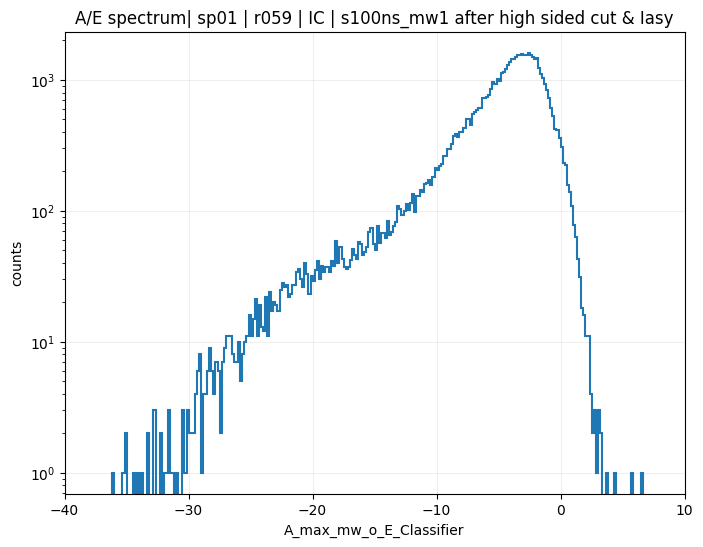

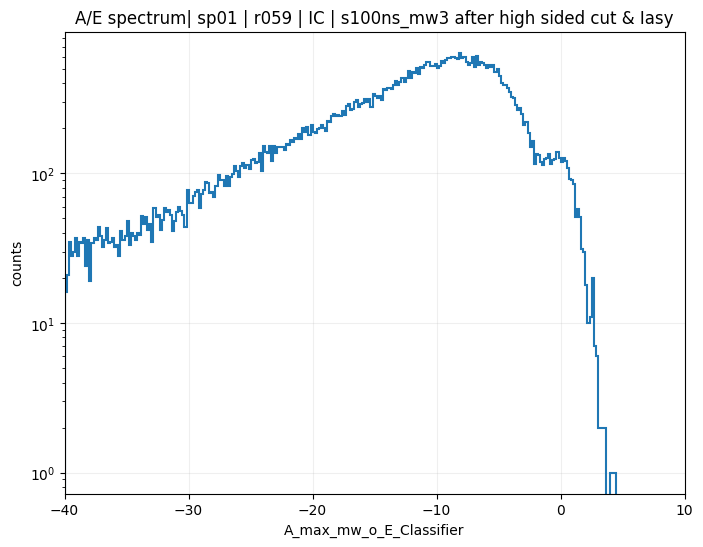

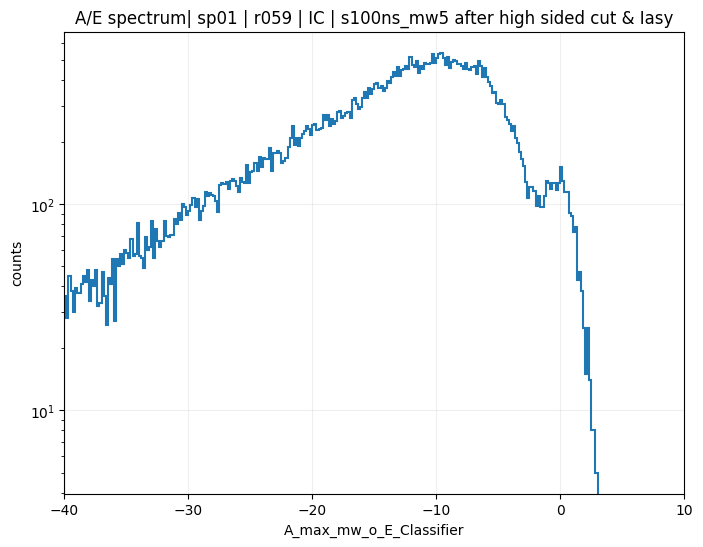

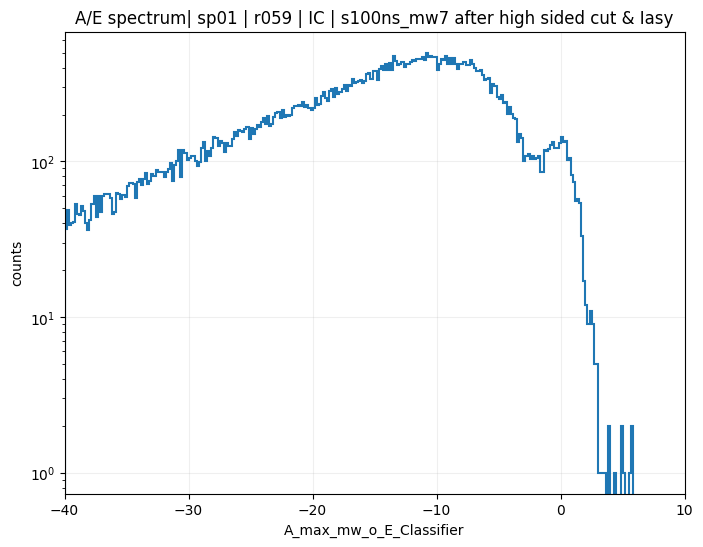

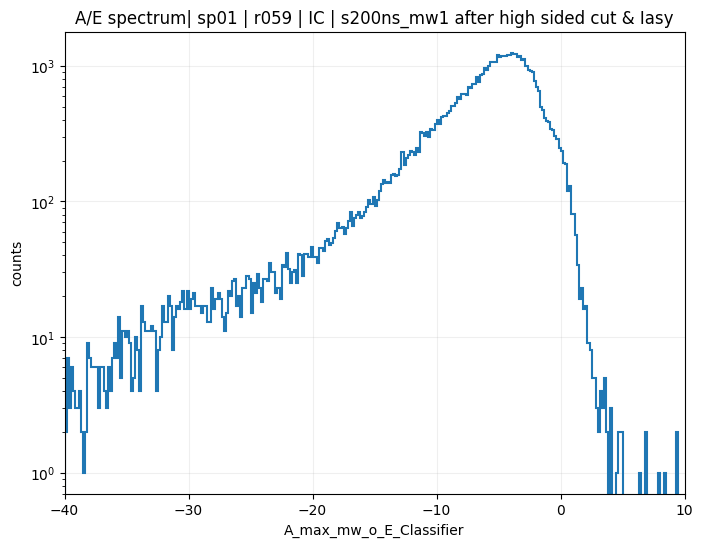

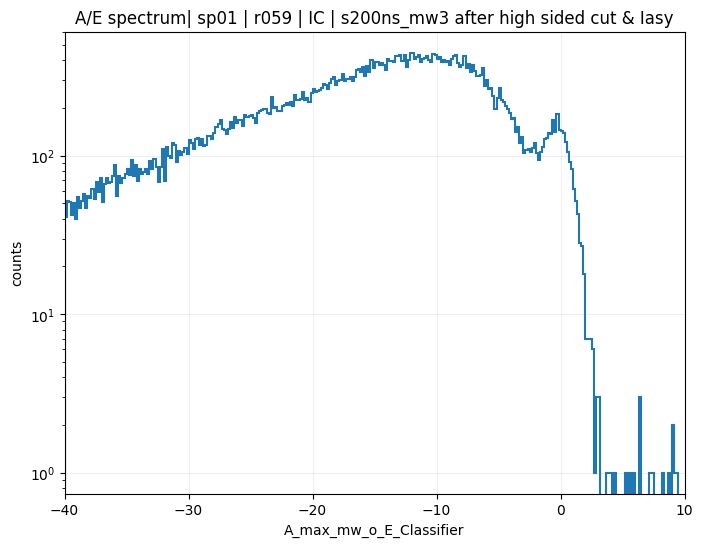

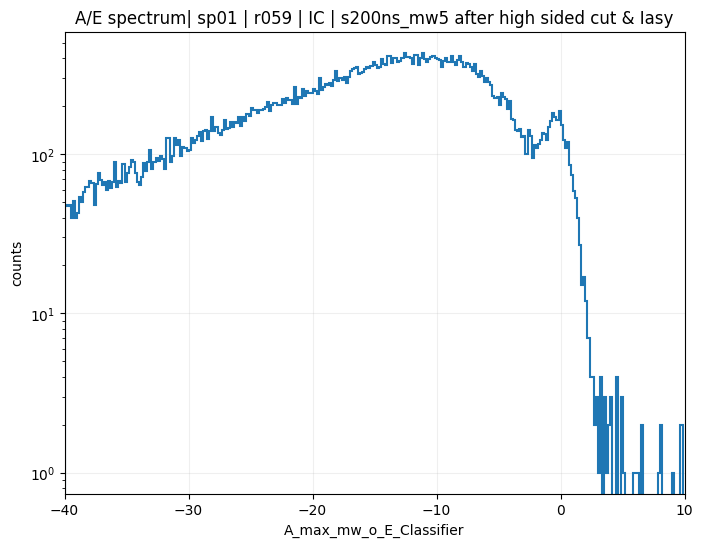

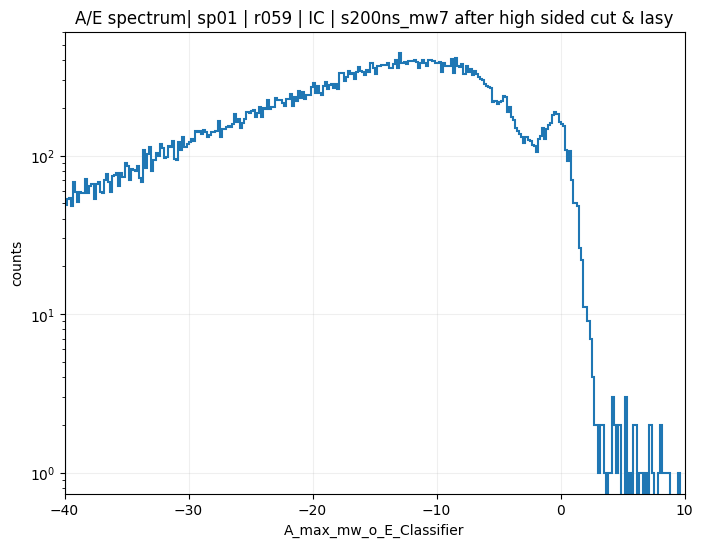

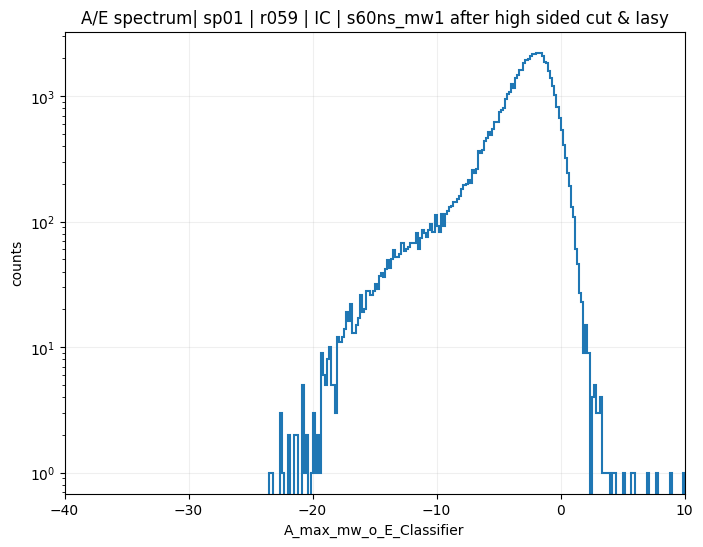

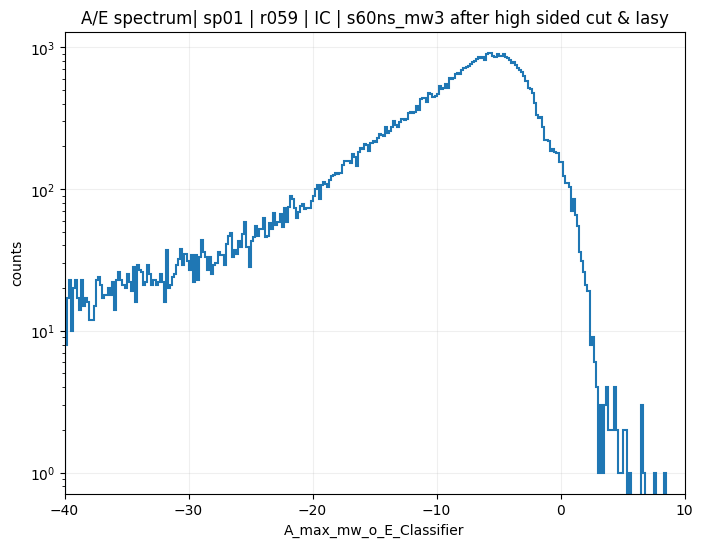

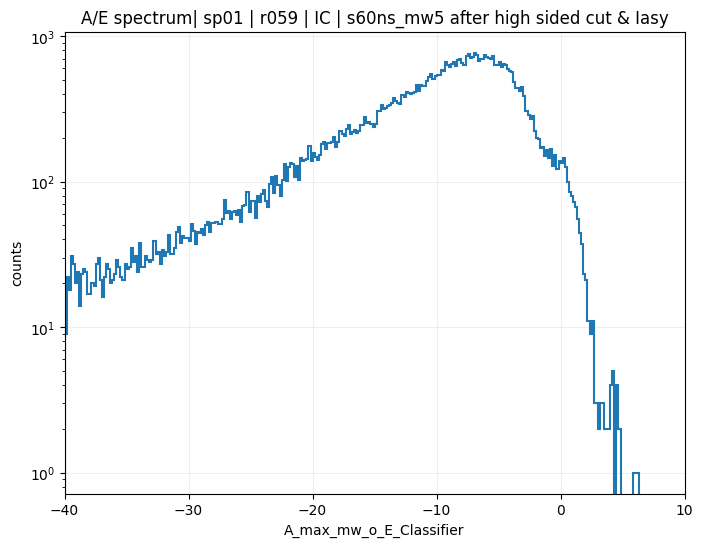

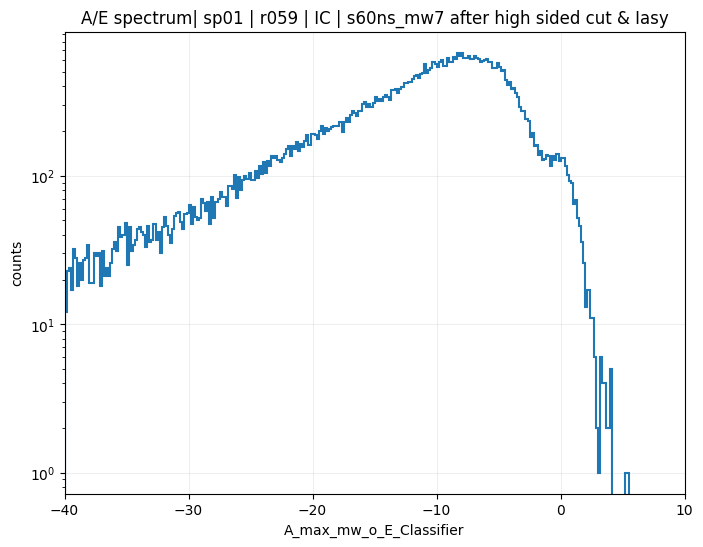

In [11]:
nbins = 300
range = (-40,10)
import matplotlib.pyplot as plt
for run in runs:
    fig,ax = plt.subplots(figsize=(8,6))
    ax.hist(A_max_mw_o_E_Classifier[run][ROI_mask], bins=nbins, range=range,histtype='step',linewidth=1.5)
    ax.grid(visible=True,alpha=0.2)
    # ax.hist(A_max_mw_o_E_Classifier[run][ROI_mask&A_max_mw_o_E_Low_Cut[run]], bins=nbins, range=range,histtype='step',label=f"{run} A_max_mw_o_E_Low_Cut")
    ax.set_xlabel("A_max_mw_o_E_Classifier")
    ax.set_ylabel("counts")
    # ax.legend()
    ax.set_xlim(range)
    ax.set_yscale('log')
    ax.set_title(f"A/E spectrum| sp01 | r059 | IC | {run} after high sided cut & Iasy")
    # ax.axvline(x=0)
    plt.show()

In [ ]:
E = np.asarray(obj['trapEftp_fix_cal'])

KeyError: 'trapEftp_fix_cal'